# Debug — Random Forest NDVI/EVI: ¿por qué cae tanto en `test_final`?

Mismo pipeline que `models/random_forest.py` (split cronológico, `prepare_features`, baseline, `GridSearchCV` con `TimeSeriesSplit`), pero desglosado en celdas y con diagnósticos agregados para investigar por qué el R² tuned en `test_final` sale negativo (ndvi: -0.27, evi: -0.06) a pesar de que el `mean_test_score` durante el tuning fue positivo (~0.23 para ndvi).

Cambia `Y_VARIABLE` en la celda de parámetros para depurar `ndvi` o `evi` sin duplicar código.

In [32]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

REPO_ROOT = Path("..").resolve()
sys.path.append(str(REPO_ROOT / "models"))

from _experiment_utils import prepare_features, split_train_val_test, compute_metrics, REGIONS

%matplotlib inline

In [33]:
# Parametros del notebook
Y_VARIABLE = "evi"  # cambiar a "evi" para depurar la otra variable
PARAM_GRID = {
    "n_estimators": [100, 200, 400],
    "max_depth": [None, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
}
RANDOM_STATE = 42
N_CV_SPLITS = 5

## 1. Cargar dataset y split cronológico (igual que `random_forest.py`)

In [34]:
DATASET_PATH = REPO_ROOT / "data" / "processed" / "dataset_modelo.csv"
df = pd.read_csv(DATASET_PATH, parse_dates=["window_start", "window_end"])

train_val, test_final = split_train_val_test(df, fecha_col="window_start", frac_test_final=0.15)
fecha_corte = test_final["window_start"].min()

split_train_val_test (fecha_col='window_start', frac_test_final=0.15):
  train_val:  2000-03-21 00:00:00 -> 2022-07-28 00:00:00  (1030 filas)
  test_final: 2022-08-13 00:00:00 -> 2026-07-12 00:00:00  (182 filas)


## 2. Preparar features (X, y) para `Y_VARIABLE`

In [35]:
X_train, y_train = prepare_features(train_val, Y_VARIABLE)
X_test, y_test = prepare_features(test_final, Y_VARIABLE)
region_train = train_val["region"].reset_index(drop=True)
region_test = test_final["region"].reset_index(drop=True)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
X_train.head()

X_train: (1030, 31)  X_test: (182, 31)


,precip_mm_lag0,pet_mm_lag0,tmean_c_lag0,dewpoint_c_lag0,soil_moist_layer1_lag0,lai_high_lag0,tmax_c_lag0,tmin_c_lag0,precip_mm_lag1,pet_mm_lag1,...,lai_high_lag2,tmax_c_lag2,tmin_c_lag2,precip_mm_roll32,et_mm_lag0,et_mm_lag1,deficit_hidrico,soil_moist_anomaly,region_Cauca,region_Narino
0,308.838170,78.502955,17.429458,15.398229,0.448579,3.960731,22.274934,13.857900,256.290696,89.980511,...,3.967131,21.425420,14.169214,565.128866,3.418989,NaN,230.335215,0.003449,True,False
1,299.504160,78.946310,19.195291,17.278268,0.439088,3.958413,23.285561,16.377707,228.588064,87.017957,...,3.931856,22.974853,16.104794,528.092225,3.460628,NaN,220.557851,0.004424,False,True
2,220.562626,78.054212,19.553304,17.677293,0.439960,3.965994,23.751420,17.091832,299.504160,78.946310,...,3.944962,24.003275,16.749589,520.066786,3.574957,3.460628,142.508413,0.002993,False,True
3,306.598302,72.498622,17.747467,15.811758,0.449493,3.971305,22.115117,15.032311,308.838170,78.502955,...,3.953886,22.763727,14.107301,615.436472,3.565069,3.418989,234.099680,0.003635,True,False
4,394.780799,69.538638,17.900326,16.012231,0.450129,3.961117,22.003388,14.863647,306.598302,72.498622,...,3.960731,22.274934,13.857900,701.379101,3.565069,3.418989,325.242161,0.003290,True,False


## 3. Baseline y tuned (mismo procedimiento que el script)

In [36]:
baseline = RandomForestRegressor(random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
r2_b, rmse_b, pearson_b = compute_metrics(y_test, baseline.predict(X_test))
print(f"baseline -> R2={r2_b:.4f}  RMSE={rmse_b:.4f}  Pearson={pearson_b:.4f}")

baseline -> R2=-0.3570  RMSE=0.0611  Pearson=0.2644


In [15]:
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=PARAM_GRID,
    cv=TimeSeriesSplit(n_splits=N_CV_SPLITS),
    scoring="r2",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
cv_results = pd.DataFrame(grid.cv_results_)

tuned = grid.best_estimator_
y_pred = tuned.predict(X_test)
r2_t, rmse_t, pearson_t = compute_metrics(y_test, y_pred)

print("best_params:", grid.best_params_)
print(f"mejor mean_test_score en CV (train_val): {cv_results['mean_test_score'].max():.4f}")
print(f"tuned en test_final                    -> R2={r2_t:.4f}  RMSE={rmse_t:.4f}  Pearson={pearson_t:.4f}")

best_params: {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 200}
mejor mean_test_score en CV (train_val): 0.1991
tuned en test_final                    -> R2=-0.0612  RMSE=0.0540  Pearson=0.4748


Nota la brecha: el `mean_test_score` (R² promedio de los 5 folds de `TimeSeriesSplit`, todos dentro de 2000-2022) suele salir bastante más alto que el R² real en `test_final` (2022-2026). Eso ya es una pista de que el problema no es de *hiperparámetros* — es que `test_final` se comporta distinto a los folds de validación usados durante el tuning. Las celdas de abajo investigan por qué.

## 4. ¿Las features de `test_final` caen fuera del rango visto en `train_val`? (extrapolación)

Un Random Forest no puede extrapolar: si en test aparecen valores fuera del rango que vio en entrenamiento, predice con las hojas de los árboles más cercanas del rango de entrenamiento, no con la relación real fuera de ese rango.

In [27]:
rango = []
for col in X_train.columns:
    tr_min, tr_max = X_train[col].min(), X_train[col].max()
    te_min, te_max = X_test[col].min(), X_test[col].max()
    fuera = (te_min < tr_min) or (te_max > tr_max)
    rango.append({
        "feature": col,
        "train_min": tr_min, "train_max": tr_max,
        "test_min": te_min, "test_max": te_max,
        "test_fuera_de_rango_train": fuera,
    })
rango_df = pd.DataFrame(rango)
print(f"Features con algún valor de test fuera del rango de train: {rango_df['test_fuera_de_rango_train'].sum()} / {len(rango_df)}")
rango_df[rango_df["test_fuera_de_rango_train"]]

Features con algún valor de test fuera del rango de train: 26 / 31


,feature,train_min,train_max,test_min,test_max,test_fuera_de_rango_train
0,precip_mm_lag0,107.067596,492.831716,63.365176,486.218494,True
1,pet_mm_lag0,54.000262,126.151434,47.104899,136.155144,True
2,tmean_c_lag0,17.007082,21.284515,17.386713,21.596573,True
3,dewpoint_c_lag0,13.785094,19.088566,14.547502,19.228684,True
4,soil_moist_layer1_lag0,0.376668,0.452346,0.361016,0.451588,True
6,tmax_c_lag0,21.209909,25.670697,21.847836,26.103944,True
7,tmin_c_lag0,11.863735,18.470899,13.602932,18.747391,True
8,precip_mm_lag1,107.067596,492.831716,63.365176,486.218494,True
9,pet_mm_lag1,54.000262,126.151434,47.104899,136.155144,True
10,tmean_c_lag1,17.007082,21.284515,17.386713,21.596573,True


## 5. Serie de tiempo real de la variable Y, con el corte train/test marcado

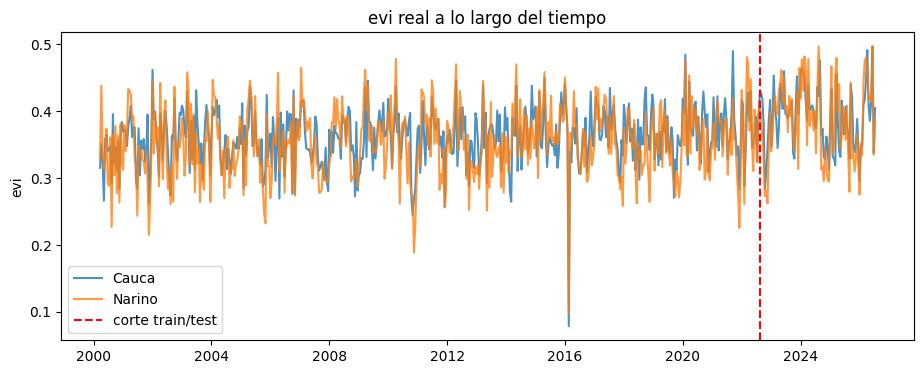

In [37]:
fig, ax = plt.subplots(figsize=(11, 4))
for region in REGIONS:
    sub = df[df["region"] == region].sort_values("window_start")
    ax.plot(sub["window_start"], sub[Y_VARIABLE], label=region, alpha=0.8)
ax.axvline(fecha_corte, color="red", linestyle="--", label="corte train/test")
ax.set_title(f"{Y_VARIABLE} real a lo largo del tiempo")
ax.set_ylabel(Y_VARIABLE)
ax.legend()
plt.show()

## 6. Promedio anual por región — ¿hay una tendencia o quiebre estructural?

region,Cauca,Narino
year,,
2000,0.337403,0.330802
2001,0.350286,0.339389
2002,0.363796,0.348114
2003,0.364774,0.344990
2004,0.355962,0.347471
2005,0.355313,0.345459
2006,0.355645,0.346952
2007,0.345502,0.342362
2008,0.358335,0.357339


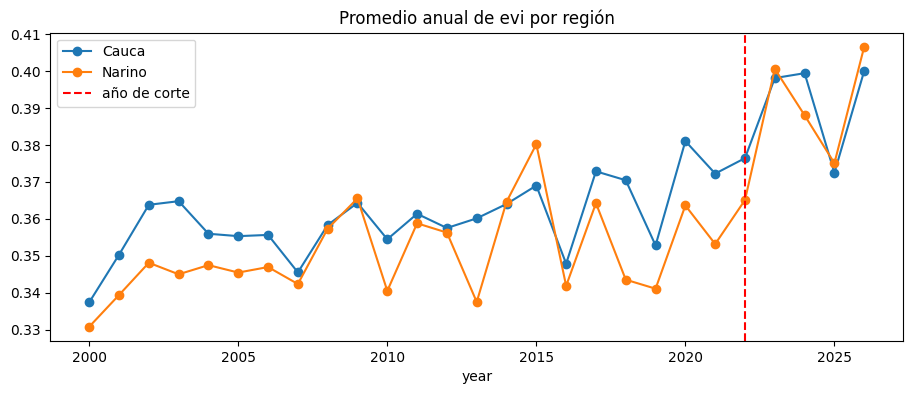

In [38]:
df_anual = df.copy()
df_anual["year"] = df_anual["window_start"].dt.year
tabla_anual = df_anual.groupby(["region", "year"])[Y_VARIABLE].mean().unstack(level=0)
display(tabla_anual)

fig, ax = plt.subplots(figsize=(11, 4))
tabla_anual.plot(ax=ax, marker="o")
ax.axvline(fecha_corte.year, color="red", linestyle="--", label="año de corte")
ax.set_title(f"Promedio anual de {Y_VARIABLE} por región")
ax.legend()
plt.show()

### ¿Las variables climáticas (X) se mantuvieron estables en el mismo periodo?

Mismo tipo de gráfica de línea anual por región, pero para algunas variables de entrada (no todas) directamente desde `data/clean/clima/era5_diario.csv` — sin pasar por las ventanas/lags, para ver la serie cruda. Si estas se ven estables mientras ndvi/evi da un salto, el salto es más difícil de explicar por el clima.

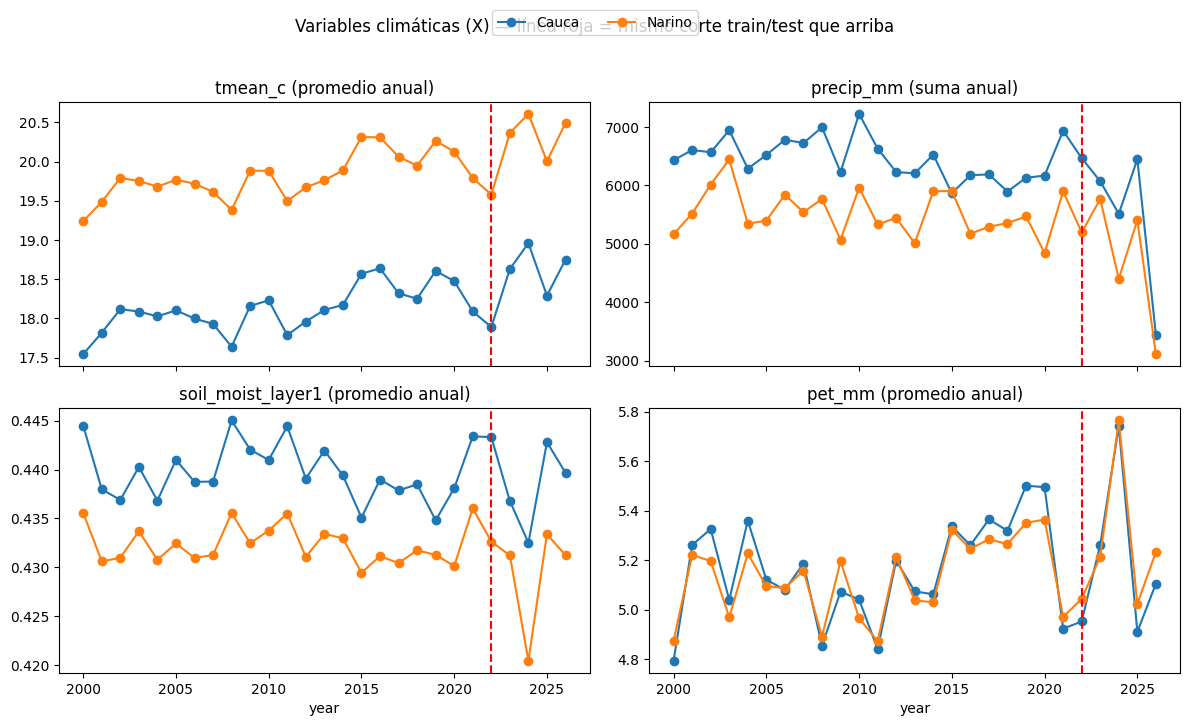

In [39]:
ERA5_DIARIO_PATH = REPO_ROOT / "data" / "clean" / "clima" / "era5_diario.csv"
era5_diario = pd.read_csv(ERA5_DIARIO_PATH, parse_dates=["date"])
era5_diario["year"] = era5_diario["date"].dt.year

# Solo algunas variables de X, elegidas para representar distintos tipos de
# comportamiento (temperatura, precipitación, humedad de suelo, PET) — no se
# grafican las 8 para no saturar la grilla.
VARIABLES_X_CHEQUEO = {
    "tmean_c": "mean",
    "precip_mm": "sum",
    "soil_moist_layer1": "mean",
    "pet_mm": "mean",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, (var, agg) in zip(axes.flat, VARIABLES_X_CHEQUEO.items()):
    tabla_var = era5_diario.groupby(["region", "year"])[var].agg(agg).unstack(level=0)
    tabla_var.plot(ax=ax, marker="o", legend=False)
    ax.axvline(fecha_corte.year, color="red", linestyle="--")
    ax.set_title(f"{var} ({'suma anual' if agg == 'sum' else 'promedio anual'})")

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Variables climáticas (X) — línea roja = mismo corte train/test que arriba", y=1.02)
fig.tight_layout()
plt.show()

**Comparación cuantitativa 2001-2022 vs. 2023-2025** (excluyendo 2000 y 2026 por ser años parciales): `tmean_c` +2.4%/+2.5% (Cauca/Nariño), `precip_mm` **-7.1%/-6.2%** (bajó, no subió), `soil_moist_layer1` -0.5%/-0.9% (estable), `pet_mm` +2.7%/+3.8%. Todo dentro de variabilidad normal o de una tendencia gradual de calentamiento de fondo — muy lejos del +12%/+14% que da `ndvi` en el mismo corte. Y precipitación bajando es climatológicamente lo opuesto de lo que explicaría un NDVI más alto. Ninguna variable de clima acompaña el salto de NDVI/EVI, lo que apunta más hacia un artefacto de extracción (ver el punto siguiente) que a una señal climática real.

**Pista para seguir investigando:** en una corrida exploratoria, el promedio anual de `ndvi` se mantiene en un rango relativamente estable entre 2000-2022 (~0.52-0.60 en Cauca, ~0.48-0.57 en Nariño) y luego **sube de forma sostenida en 2023-2026** (~0.61-0.67 en ambas regiones) — justo el tramo que cae en `test_final`. Un salto de nivel así, simultáneo en las dos regiones, es más compatible con un cambio de *cómo se mide* el dato que con un cambio real de vegetación tan grande en tan poco tiempo. Antes de asumir que es señal real, vale la pena descartar un artefacto de extracción: **[`03_extract_modis.py`](../scripts/etl/03_extract_modis.py) promedia NDVI/EVI sobre todo el polígono departamental sin filtrar por la banda de calidad de MOD13Q1 (`SummaryQA`/`DetailedQA`, píxeles con nubes/nieve/baja confiabilidad)** — si la mezcla de píxeles de baja calidad incluidos en el promedio cambió entre años (por disponibilidad de escenas, cobertura de nubes, o reprocesamiento de la colección), eso podría producir justo este tipo de corrimiento sin que sea vegetación real. Sugerencia concreta: re-extraer MOD13Q1 filtrando por `SummaryQA == 0` ("buena calidad") y comparar el promedio anual — si el salto desaparece o se reduce, confirma la hipótesis.

### Verificación: ¿el filtro por `SummaryQA` reduce el salto?

Se modificó [`03_extract_modis.py`](../scripts/etl/03_extract_modis.py) para enmascarar píxeles con `SummaryQA` fuera de {0, 1} (descarta nieve/hielo y nube) antes de promediar por región, y se corrió de nuevo — sin sobreescribir el archivo original — guardando el resultado en `data/raw/ndvi_evi/modis_16dias_qa_filtrado.csv`. Misma gráfica de "promedio anual por región" de arriba, pero ahora superponiendo la serie original (sin filtrar) y la filtrada, directamente desde los dos CSV crudos.

region,Cauca,Narino
year,,
2000,0.450478,0.469052
2001,0.436858,0.439900
2002,0.451368,0.463182
2003,0.453768,0.460389
2004,0.439687,0.451346
2005,0.446180,0.460739
2006,0.447956,0.466381
2007,0.450610,0.464038
2008,0.464855,0.478815


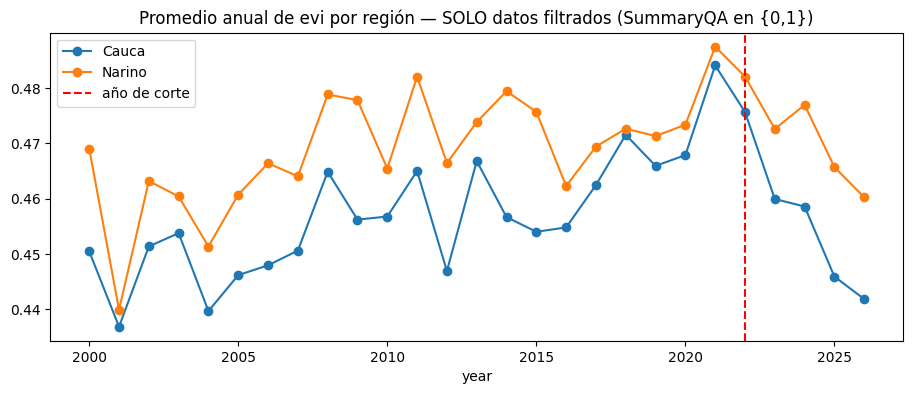

Cambio % 2001-2022 -> 2023-2025, evi FILTRADO: {'Cauca': -0.7, 'Narino': 0.5}


In [40]:
MODIS_QA_PATH = REPO_ROOT / "data" / "raw" / "ndvi_evi" / "modis_16dias_qa_filtrado.csv"

modis_qa = pd.read_csv(MODIS_QA_PATH, parse_dates=["date"])
modis_qa["year"] = modis_qa["date"].dt.year

tabla_qa = modis_qa.groupby(["region", "year"])[Y_VARIABLE].mean().unstack(level=0)
display(tabla_qa)

fig, ax = plt.subplots(figsize=(11, 4))
tabla_qa.plot(ax=ax, marker="o")
ax.axvline(fecha_corte.year, color="red", linestyle="--", label="año de corte")
ax.set_title(f"Promedio anual de {Y_VARIABLE} por región — SOLO datos filtrados (SummaryQA en {{0,1}})")
ax.legend()
plt.show()

pre_qa = tabla_qa.loc[2001:2022].mean()
post_qa = tabla_qa.loc[2023:2025].mean()
cambio_qa = (post_qa - pre_qa) / pre_qa.abs() * 100
print(f"Cambio % 2001-2022 -> 2023-2025, {Y_VARIABLE} FILTRADO: {cambio_qa.round(1).to_dict()}")

Compara esta gráfica visualmente con la de la sección 6 (arriba, con los datos originales sin filtrar) — ahí se veía el salto sostenido desde 2023. Si acá la serie se ve más plana en el mismo tramo (y el `cambio %` impreso arriba es mucho menor que el que se observaba con los datos originales, ~+12%/+14% en ndvi), confirma que el salto era mayormente un artefacto de píxeles de mala calidad (nube/nieve) mezclados sin filtrar en el promedio por región, no una señal real de vegetación. Nota también que el nivel absoluto de esta serie queda más alto que el de la gráfica original en todos los años — esperable, porque los píxeles nublados/con nieve tienden a bajar el NDVI/EVI aparente, y ahora se excluyen del promedio.

## 7. Real vs. predicho en `test_final` (modelo tuned)

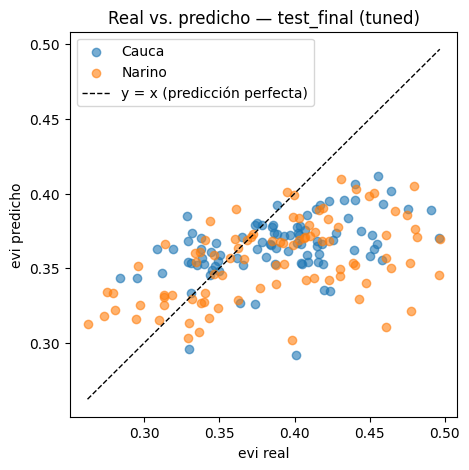

In [20]:
fig, ax = plt.subplots(figsize=(5, 5))
for region in REGIONS:
    mask = (region_test == region).values
    ax.scatter(y_test.values[mask], y_pred[mask], alpha=0.6, label=region)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, color="black", linestyle="--", linewidth=1, label="y = x (predicción perfecta)")
ax.set_xlabel(f"{Y_VARIABLE} real")
ax.set_ylabel(f"{Y_VARIABLE} predicho")
ax.set_title("Real vs. predicho — test_final (tuned)")
ax.legend()
plt.show()

Si los puntos quedan sistemáticamente **arriba** de la línea y = x (real > predicho), el modelo está subestimando la variable Y en todo `test_final` — consistente con que aprendió el nivel histórico (2000-2022) y el nivel real subió en 2023-2026.

## 8. Residuales a lo largo del tiempo

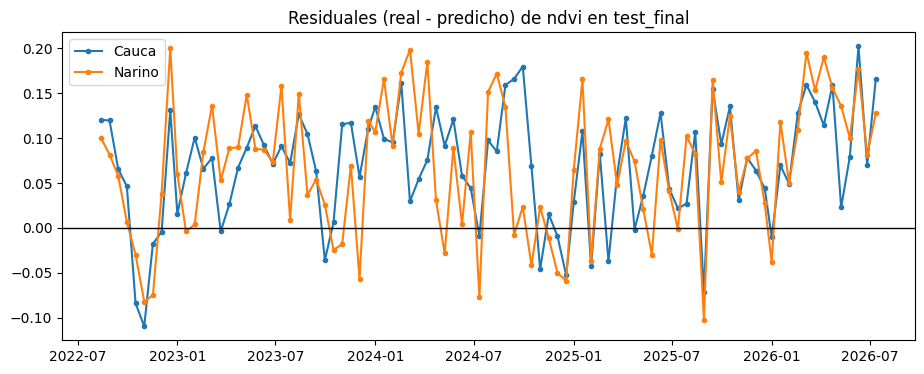

Residual medio global: 0.0682  (std=0.0686)
  Cauca: media=0.0687  std=0.0628  n=91
  Narino: media=0.0677  std=0.0740  n=91


In [11]:
residuals = y_test.values - y_pred
window_test = test_final["window_start"].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 4))
for region in REGIONS:
    mask = (region_test == region).values
    ax.plot(window_test[mask], residuals[mask], marker="o", markersize=3, label=region)
ax.axhline(0, color="black", linewidth=1)
ax.set_title(f"Residuales (real - predicho) de {Y_VARIABLE} en test_final")
ax.legend()
plt.show()

print(f"Residual medio global: {residuals.mean():.4f}  (std={residuals.std():.4f})")
for region in REGIONS:
    mask = (region_test == region).values
    print(f"  {region}: media={residuals[mask].mean():.4f}  std={residuals[mask].std():.4f}  n={mask.sum()}")

Si el residual medio es consistentemente positivo (real > predicho) y no oscila alrededor de cero, es sesgo de nivel (el modelo subestima sistemáticamente), no varianza/ruido — refuerza la hipótesis del punto 6.